# Scipy

In [35]:
!pip install scipy


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [36]:
# importation 
import numpy as np
import scipy
import matplotlib.pyplot as plt 

## 1 Interpolation

Avec Scipy on peut interpoler un signal s’il manque des données dans un dataset. Toutefois, çà peut parfois changer la réalité des choses!

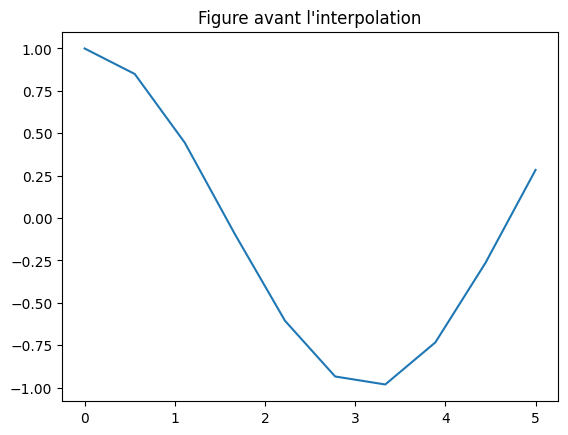

[]

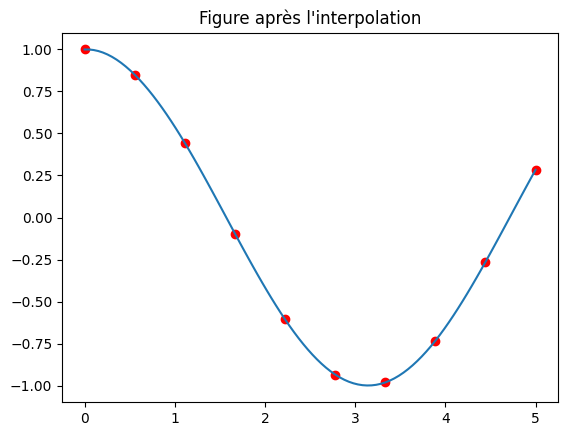

In [37]:
from scipy.interpolate import interp1d

# Créer un dataset (X, y)
X = np.linspace(0, 5, 10)
y = np.cos(X)

plt.plot(X, y)
plt.title("Figure avant l'interpolation")
plt.show()

f = interp1d(X, y, kind='cubic') # interpolation 

X_new = np.linspace(0, 5, 100)
y_new = f(X_new) # estimer les valeurs de y en X

plt.scatter(X, y, color='red', label='Données originales')
plt.plot(X_new, y_new, label='Interpolation cubique')
plt.title("Figure après l'interpolation")

plt.plot()

## 2 Optimisation

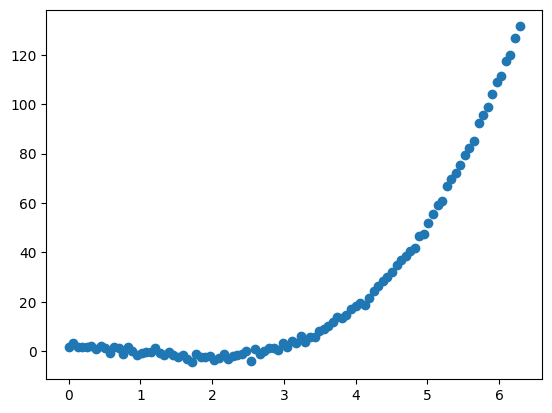

a = 1.0054767081731868
b = -3.016331386909264
c = -0.051643159068508915
d = 1.8488923390166998


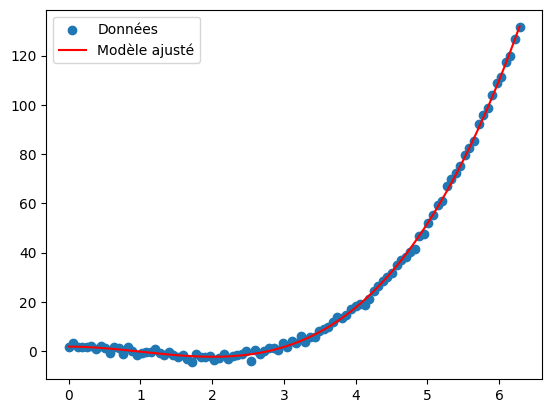

In [38]:
from scipy.optimize import curve_fit

# Créer X est un tableau de taille 100 contenant des valeurs entre 0 et 2π.
X = np.linspace(0, 2*np.pi, 100) 
epsilon = np.random.randn(X.shape[0])
y = X**3 - 3*X**2 + 2 + epsilon

plt.scatter(X, y)
plt.show()

# modéle
def f(x, a, b, c, d):
    return a*x**3 + b*x**2 + c*x + d

# Ajustement
params, params_cov = curve_fit(f, X, y)

# Récupération des paramètres
a, b, c, d = params

print("a =", a)
print("b =", b)
print("c =", c)
print("d =", d)

# Valeurs de y ajusté
y_model = f(X, a, b, c, d)

plt.scatter(X, y, label="Données")
plt.plot(X, y_model, color="red", label="Modèle ajusté")

plt.legend()
plt.show()



## 3 Minimisation unidimensionnelle (1D)

le Minimum x*: [2.59573908]
la valeur minimal: -1.8089833418214658


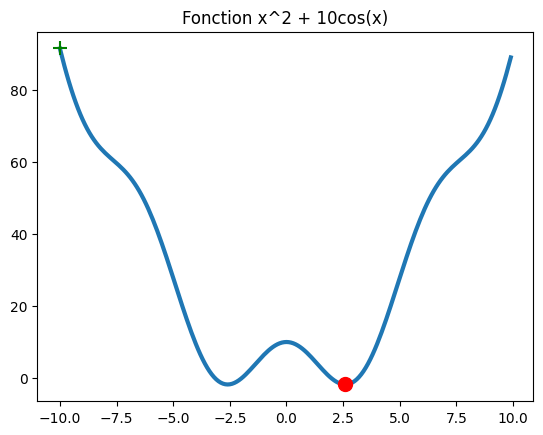

In [39]:
from scipy.optimize import minimize

# Tracer le graphique de la fonction
def f(X):
    return X**2 + 10 * np.cos(X)

X = np.arange(-10, 10, 0.1)
y = f(X)

# déterminer un minimum x⋆ de la fonction f
x0 = -10
resultat = minimize(f, x0)
x_star = resultat.x
print("le Minimum x*:", x_star)
print("la valeur minimal:", resultat.fun)

# Graphique
plt.plot(X, f(X), lw=3, zorder=-1)
plt.scatter(x_star, f(x_star), s=100, c='r', zorder=1)
plt.scatter(x0, f(x0), s=100, c='g', marker='+', zorder=1)
plt.title("Fonction x^2 + 10cos(x)")
plt.show()

## 4 Minimisation bidimensionnelle (2D)

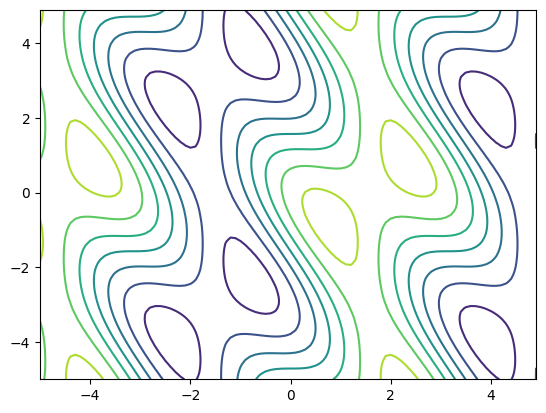

le Minimum x*: [-7.06858344 -2.35619446]
la valeur minimal: -1.414213562373093


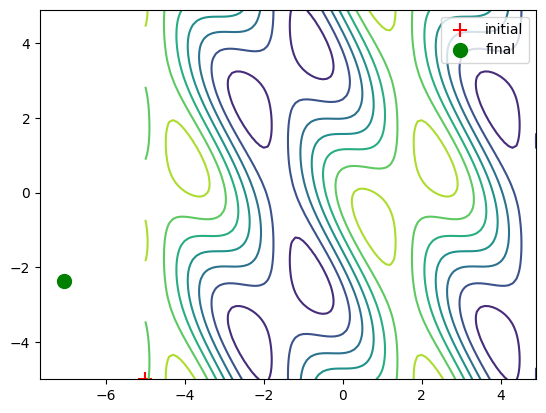

In [55]:
u = np.arange(-5, 5, 0.1)
v = np.arange(-5, 5, 0.1)
U, V = np.meshgrid(u, v)

def f(X):
    U, V = X
    return np.sin(U) + np.cos(U+V)*np.cos(U)

y = f([U, V])

plt.contour(U, V, y) # sert à tracer les lignes de niveau 
plt.show()

# déterminer un minimum x⋆ de la fonction f
x0 = [-5, -5]
resultat = minimize(f, x0)
x_star = resultat.x
print("le Minimum x*:", x_star)
print("la valeur minimal:", resultat.fun)

# Graphique
plt.contour(U, V, f([U, V])) # Fonction 2D
plt.scatter(x0[0], x0[1], marker='+', c='r', s=100, label='initial') # Point de départ
plt.scatter(x_star[0], x_star[1], c='g', s=100, label='final') # Point final
plt.legend()
plt.show()


## 5 Traitement de signal

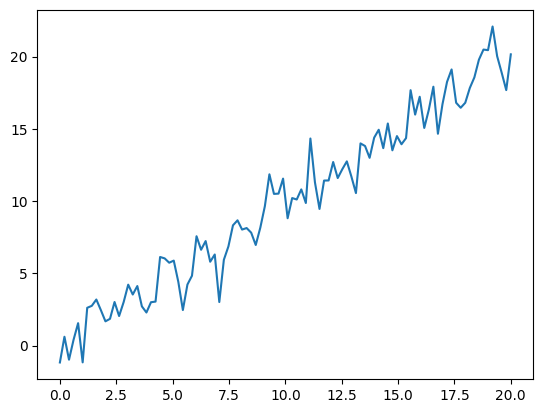

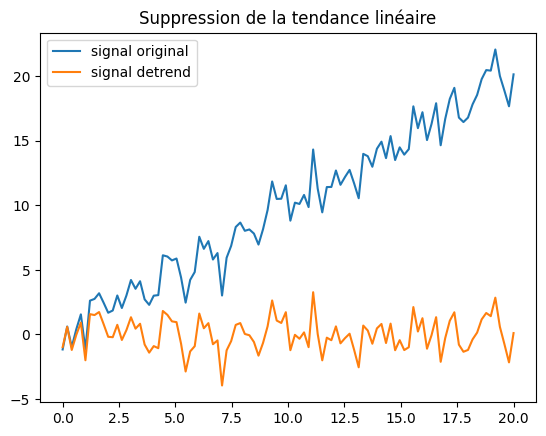

In [60]:
from scipy.signal import detrend

X = np.linspace(0, 20, 100)
y = X + np.cos(4*X) + np.random.randn(X.shape[0])
plt.plot(X, y)
plt.show()

y_detrend = detrend(y, type='linear') # élimine la tendance linéaire
plt.plot(X, y,  label='signal original')
plt.plot(X, y_detrend,  label='signal detrend')
plt.legend()
plt.title("Suppression de la tendance linéaire")

plt.show()
